In [228]:
import pandas as pd

In [229]:
data['workclass'] = data['workclass'].replace({'?': 'Others'})
data['occupation'] = data['occupation'].replace({'?': 'Others'})
data['native-country'] = data['native-country'].replace({'?': 'Others'})
data = data[data['workclass'] != 'Without-pay']
data = data[data['workclass'] != 'Never-worked']
print(data['workclass'].value_counts())
print(data['occupation'].value_counts())
print(data['native-country'].value_counts())

workclass
3    32486
5     3620
1     3052
2     2542
6     1957
4     1641
0     1422
Name: count, dtype: int64
occupation
10    6117
3     5999
2     5820
0     5541
12    5403
7     4571
6     2744
8     2542
14    2209
5     1912
13    1438
4     1260
11     965
9      184
1       15
Name: count, dtype: int64
native-country
39    42544
0       800
26      522
30      273
11      204
2       173
33      156
19      150
9       122
5       116
3       111
35      110
23      103
8        99
24       91
22       82
31       79
40       79
4        79
6        74
36       65
14       65
20       59
13       54
32       46
29       44
12       44
27       43
7        39
10       37
21       35
37       29
17       27
1        25
38       25
28       23
41       21
34       20
25       18
18       17
16       16
15        1
Name: count, dtype: int64


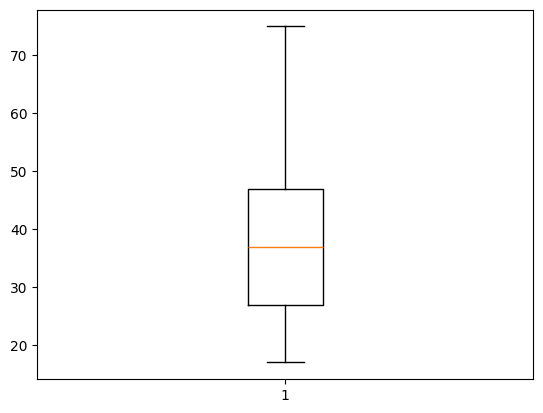

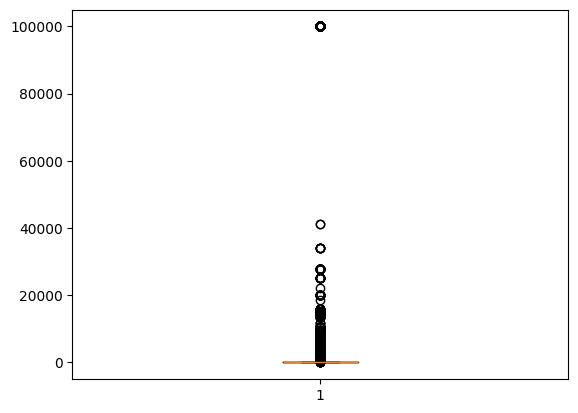

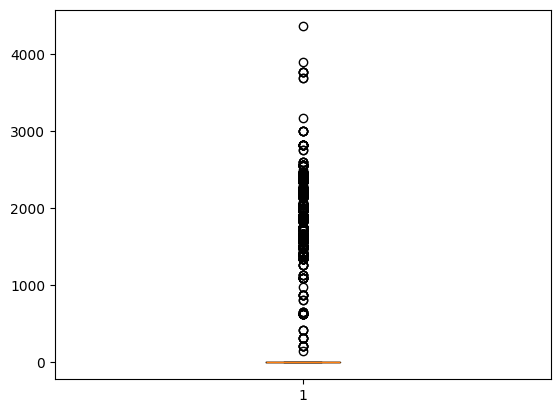

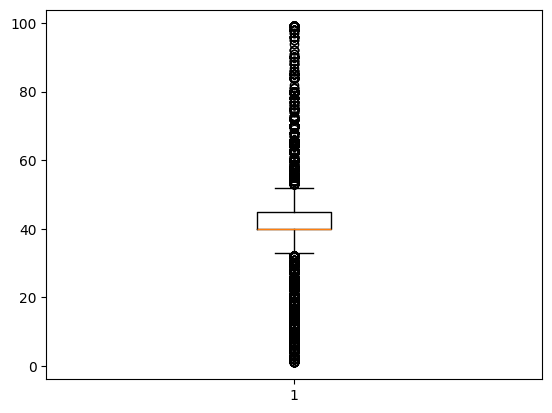

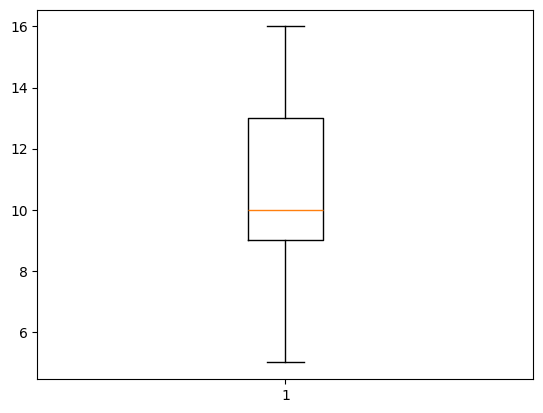

(46720, 14)


In [230]:
import matplotlib.pyplot as plt
plt.boxplot(data['age'])
plt.show()
plt.boxplot(data['capital-gain'])
plt.show()
plt.boxplot(data['capital-loss'])
plt.show()
plt.boxplot(data['hours-per-week'])
plt.show()
plt.boxplot(data['educational-num'])
plt.show()
data = data[(data['age'] <= 75) & (data['age'] >= 17)]
data = data[(data['educational-num'] <= 16) & (data['educational-num'] >= 5)]
print(data.shape)

In [231]:
display(data.head())

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,7,4,6,3,2,1,0,0,40,39,0
1,38,3,89814,9,2,4,0,4,1,0,0,50,39,0
2,28,1,336951,12,2,11,0,4,1,0,0,40,39,1
3,44,3,160323,10,2,6,0,2,1,7688,0,40,39,1
4,18,2,103497,10,4,8,3,4,0,0,0,30,39,0


In [232]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
categorical_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])
x = data.drop(columns=['income'])
y = data['income']
display(x.head())
display(y.head())

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,3,226802,7,4,6,3,2,1,0,0,40,39
1,38,3,89814,9,2,4,0,4,1,0,0,50,39
2,28,1,336951,12,2,11,0,4,1,0,0,40,39
3,44,3,160323,10,2,6,0,2,1,7688,0,40,39
4,18,2,103497,10,4,8,3,4,0,0,0,30,39


,income
0,0
1,0
2,1
3,1
4,0


In [233]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier

models = {
    "DecisionTree": DecisionTreeClassifier(),
    "SVM_RBF": SVC(kernel='rbf'),
    "AdaBoost": AdaBoostClassifier()
}

In [235]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    try:
        auc = roc_auc_score(y_test, y_pred)
        print(f"{name} AUC: {auc:.4f}")
        results[name] = {'Accuracy': acc, 'AUC': auc}
    except ValueError:
        print(f"{name} AUC could not be calculated (requires binary labels).")
        results[name] = {'Accuracy': acc, 'AUC': None}

DecisionTree Accuracy: 0.8010
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      7010
           1       0.60      0.62      0.61      2334

    accuracy                           0.80      9344
   macro avg       0.73      0.74      0.74      9344
weighted avg       0.80      0.80      0.80      9344

DecisionTree AUC: 0.7397
SVM_RBF Accuracy: 0.7884
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      7010
           1       0.97      0.16      0.27      2334

    accuracy                           0.79      9344
   macro avg       0.88      0.58      0.57      9344
weighted avg       0.83      0.79      0.73      9344

SVM_RBF AUC: 0.5781
AdaBoost Accuracy: 0.8411
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      7010
           1       0.77      0.52      0.62      2334

    accuracy                           0.84      9344
  

In [214]:
from sklearn.model_selection import GridSearchCV
import numpy as np

best_model_name_acc = max(results, key=lambda k: results[k]['Accuracy'])
best_model_name_auc = max(results, key=lambda k: results[k]['AUC'] if results[k]['AUC'] is not None else -1)

print(f"Best model based on Accuracy: {best_model_name_acc}")
print(f"Best model based on AUC: {best_model_name_auc}")

tuned_results = {}

if best_model_name_acc == "DecisionTree":
    dt_param_grid = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    dt_grid_search = GridSearchCV(models["DecisionTree"], dt_param_grid, cv=5, scoring='accuracy')
    dt_grid_search.fit(X_train, y_train)
    tuned_results["Tuned_DecisionTree"] = {'Accuracy': dt_grid_search.best_score_, 'AUC': None}
    print(f"Tuned DecisionTree Best Params (Accuracy): {dt_grid_search.best_params_}")
    print(f"Tuned DecisionTree Best Cross-Validation Accuracy: {dt_grid_search.best_score_:.4f}")


if best_model_name_auc == "DecisionTree" and best_model_name_acc != "DecisionTree":
    dt_param_grid_auc = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    dt_grid_search_auc = GridSearchCV(models["DecisionTree"], dt_param_grid_auc, cv=5, scoring='roc_auc')
    dt_grid_search_auc.fit(X_train, y_train)
    if "Tuned_DecisionTree" not in tuned_results or tuned_results["Tuned_DecisionTree"]['AUC'] is None or dt_grid_search_auc.best_score_ > tuned_results["Tuned_DecisionTree"]['AUC']:
         tuned_results["Tuned_DecisionTree"] = {'Accuracy': None, 'AUC': dt_grid_search_auc.best_score_}
    print(f"Tuned DecisionTree Best Params (AUC): {dt_grid_search_auc.best_params_}")
    print(f"Tuned DecisionTree Best Cross-Validation AUC: {dt_grid_search_auc.best_score_:.4f}")


if best_model_name_acc == "AdaBoost":
    ab_param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
    ab_grid_search = GridSearchCV(models["AdaBoost"], ab_param_grid, cv=5, scoring='accuracy')
    ab_grid_search.fit(X_train, y_train)
    tuned_results["Tuned_AdaBoost"] = {'Accuracy': ab_grid_search.best_score_, 'AUC': None}
    print(f"Tuned AdaBoost Best Params (Accuracy): {ab_grid_search.best_params_}")
    print(f"Tuned AdaBoost Best Cross-Validation Accuracy: {ab_grid_search.best_score_:.4f}")

if best_model_name_auc == "AdaBoost" and best_model_name_acc != "AdaBoost":
    ab_param_grid_auc = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
    ab_grid_search_auc = GridSearchCV(models["AdaBoost"], ab_param_grid_auc, cv=5, scoring='roc_auc')
    ab_grid_search_auc.fit(X_train, y_train)
    if "Tuned_AdaBoost" not in tuned_results or tuned_results["Tuned_AdaBoost"]['AUC'] is None or ab_grid_search_auc.best_score_ > tuned_results["Tuned_AdaBoost"]['AUC']:
         tuned_results["Tuned_AdaBoost"] = {'Accuracy': None, 'AUC': ab_grid_search_auc.best_score_}
    print(f"Tuned AdaBoost Best Params (AUC): {ab_grid_search_auc.best_params_}")
    print(f"Tuned AdaBoost Best Cross-Validation AUC: {ab_grid_search_auc.best_score_:.4f}")


results.update(tuned_results)

Best model based on Accuracy: AdaBoost
Best model based on AUC: DecisionTree
Tuned DecisionTree Best Params (AUC): {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Tuned DecisionTree Best Cross-Validation AUC: 0.8975
Tuned AdaBoost Best Params (Accuracy): {'learning_rate': 1.0, 'n_estimators': 200}
Tuned AdaBoost Best Cross-Validation Accuracy: 0.8555


In [215]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

if "Tuned_DecisionTree" in tuned_results and tuned_results["Tuned_DecisionTree"]['AUC'] is not None:
    tuned_dt_model = GridSearchCV(models["DecisionTree"], dt_param_grid_auc, cv=5, scoring='roc_auc').fit(X_train, y_train).best_estimator_
    y_pred_tuned_dt = tuned_dt_model.predict(X_test)
    acc_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
    auc_tuned_dt = roc_auc_score(y_test, y_pred_tuned_dt)
    results["Tuned_DecisionTree"]['Accuracy'] = acc_tuned_dt
    results["Tuned_DecisionTree"]['AUC'] = auc_tuned_dt
    print("Tuned DecisionTree Test Performance:")
    print(f"Accuracy: {acc_tuned_dt:.4f}")
    print(f"AUC: {auc_tuned_dt:.4f}")
    print(classification_report(y_test, y_pred_tuned_dt))

if "Tuned_AdaBoost" in tuned_results and tuned_results["Tuned_AdaBoost"]['Accuracy'] is not None:
    tuned_ab_model = GridSearchCV(models["AdaBoost"], ab_param_grid, cv=5, scoring='accuracy').fit(X_train, y_train).best_estimator_
    y_pred_tuned_ab = tuned_ab_model.predict(X_test)
    acc_tuned_ab = accuracy_score(y_test, y_pred_tuned_ab)
    try:
        auc_tuned_ab = roc_auc_score(y_test, y_pred_tuned_ab)
        results["Tuned_AdaBoost"]['AUC'] = auc_tuned_ab
        print("Tuned AdaBoost Test Performance:")
        print(f"Accuracy: {acc_tuned_ab:.4f}")
        print(f"AUC: {auc_tuned_ab:.4f}")
        print(classification_report(y_test, y_pred_tuned_ab))
    except ValueError:
        results["Tuned_AdaBoost"]['AUC'] = None
        print("Tuned AdaBoost Test Performance:")
        print(f"Accuracy: {acc_tuned_ab:.4f}")
        print("AUC could not be calculated (requires binary labels).")
        print(classification_report(y_test, y_pred_tuned_ab))

Tuned DecisionTree Test Performance:
Accuracy: 0.8502
AUC: 0.7712
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7010
           1       0.74      0.61      0.67      2334

    accuracy                           0.85      9344
   macro avg       0.81      0.77      0.79      9344
weighted avg       0.84      0.85      0.85      9344

Tuned AdaBoost Test Performance:
Accuracy: 0.8485
AUC: 0.7630
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      7010
           1       0.75      0.59      0.66      2334

    accuracy                           0.85      9344
   macro avg       0.81      0.76      0.78      9344
weighted avg       0.84      0.85      0.84      9344



In [216]:
best_model_name = None
best_accuracy = -1
best_auc = -1

for name, metrics in results.items():
    acc = metrics['Accuracy']
    auc = metrics['AUC']

    if acc is not None and auc is not None:
        combined_score = acc * 0.5 + auc * 0.5
        if combined_score > (best_accuracy * 0.5 + best_auc * 0.5):
            best_accuracy = acc
            best_auc = auc
            best_model_name = name
    elif acc is not None:
        if acc > best_accuracy:
            best_accuracy = acc
            best_model_name = name
            best_auc = auc

print(f"Based on a combination of Accuracy and AUC (or Accuracy if AUC not available):")
print(f"Best Performing Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]['Accuracy']:.4f}")
if results[best_model_name]['AUC'] is not None:
    print(f"AUC: {results[best_model_name]['AUC']:.4f}")

if best_model_name in ["DecisionTree", "Tuned_DecisionTree"]:
    if "Tuned_DecisionTree" in results:
        final_best_model = GridSearchCV(models["DecisionTree"], dt_param_grid_auc, cv=5, scoring='roc_auc').fit(X_train, y_train).best_estimator_
    else:
        final_best_model = models["DecisionTree"].fit(X_train, y_train)

    print("\nFeature Importances for Decision Tree:")
    feature_importances = pd.Series(final_best_model.feature_importances_, index=x.columns)
    print(feature_importances.sort_values(ascending=False))

elif best_model_name in ["AdaBoost", "Tuned_AdaBoost"]:
    if "Tuned_AdaBoost" in results:
         final_best_model = GridSearchCV(models["AdaBoost"], ab_param_grid, cv=5, scoring='accuracy').fit(X_train, y_train).best_estimator_
    else:
        final_best_model = models["AdaBoost"].fit(X_train, y_train)

    print("\nFeature Importances for AdaBoost:")
    feature_importances = pd.Series(final_best_model.feature_importances_, index=x.columns)
    print(feature_importances.sort_values(ascending=False))

Based on a combination of Accuracy and AUC (or Accuracy if AUC not available):
Best Performing Model: Tuned_DecisionTree
Accuracy: 0.8502
AUC: 0.7712

Feature Importances for Decision Tree:
relationship       0.409247
capital-gain       0.204042
educational-num    0.184649
capital-loss       0.068798
age                0.045977
hours-per-week     0.041409
fnlwgt             0.015874
workclass          0.011641
occupation         0.011419
native-country     0.003245
gender             0.001912
race               0.001147
marital-status     0.000640
dtype: float64


In [217]:
import joblib
joblib.dump(final_best_model, "best_model.pkl")
print("✅ Trained model saved as best_model.pkl")

✅ Trained model saved as best_model.pkl


In [218]:
data['workclass'] = data['workclass'].replace({'?': 'Others'})
data['occupation'] = data['occupation'].replace({'?': 'Others'})
data['native-country'] = data['native-country'].replace({'?': 'Others'})
data = data[data['workclass'] != 'Without-pay']
data = data[data['workclass'] != 'Never-worked']
print(data['workclass'].value_counts())
print(data['occupation'].value_counts())
print(data['native-country'].value_counts())

workclass
3    32486
5     3620
1     3052
2     2542
6     1957
4     1641
0     1422
Name: count, dtype: int64
occupation
10    6117
3     5999
2     5820
0     5541
12    5403
7     4571
6     2744
8     2542
14    2209
5     1912
13    1438
4     1260
11     965
9      184
1       15
Name: count, dtype: int64
native-country
39    42544
0       800
26      522
30      273
11      204
2       173
33      156
19      150
9       122
5       116
3       111
35      110
23      103
8        99
24       91
22       82
31       79
40       79
4        79
6        74
36       65
14       65
20       59
13       54
32       46
29       44
12       44
27       43
7        39
10       37
21       35
37       29
17       27
1        25
38       25
28       23
41       21
34       20
25       18
18       17
16       16
15        1
Name: count, dtype: int64


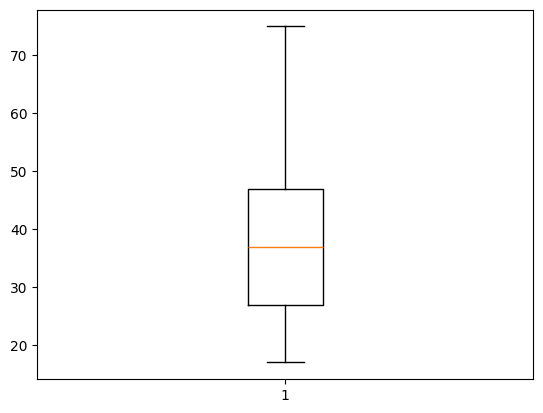

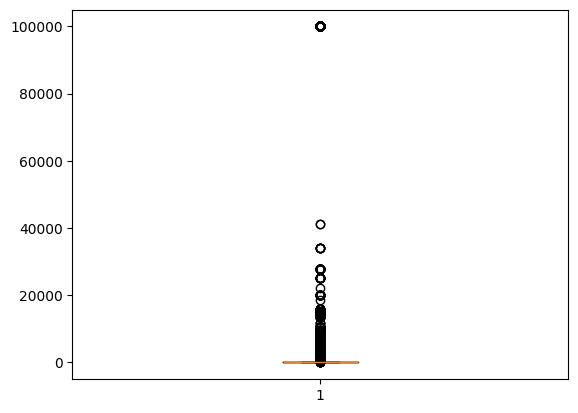

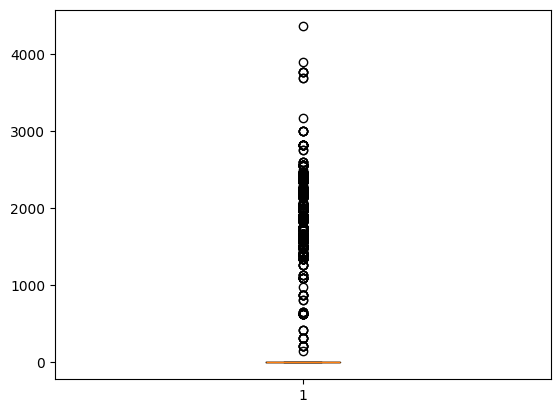

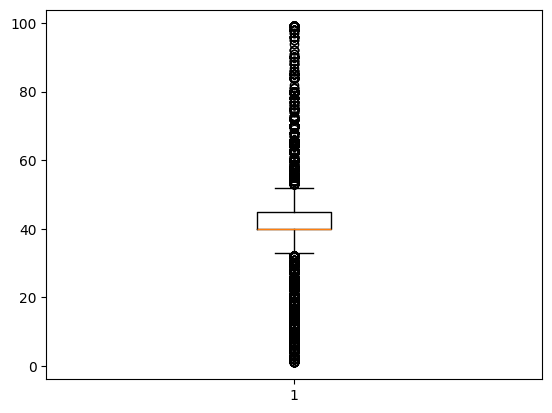

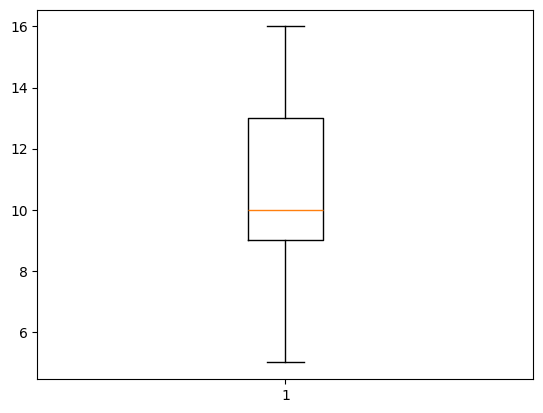

(46720, 14)


In [219]:
import matplotlib.pyplot as plt
plt.boxplot(data['age'])
plt.show()
plt.boxplot(data['capital-gain'])
plt.show()
plt.boxplot(data['capital-loss'])
plt.show()
plt.boxplot(data['hours-per-week'])
plt.show()
plt.boxplot(data['educational-num'])
plt.show()
data = data[(data['age'] <= 75) & (data['age'] >= 17)]
data = data[(data['educational-num'] <= 16) & (data['educational-num'] >= 5)]
print(data.shape)

In [220]:
display(data.head())

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,3,226802,7,4,6,3,2,1,0,0,40,39,0
1,38,3,89814,9,2,4,0,4,1,0,0,50,39,0
2,28,1,336951,12,2,11,0,4,1,0,0,40,39,1
3,44,3,160323,10,2,6,0,2,1,7688,0,40,39,1
4,18,2,103497,10,4,8,3,4,0,0,0,30,39,0


In [221]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
categorical_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])
x = data.drop(columns=['income'])
y = data['income']
display(x.head())
display(y.head())

,age,workclass,fnlwgt,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,3,226802,7,4,6,3,2,1,0,0,40,39
1,38,3,89814,9,2,4,0,4,1,0,0,50,39
2,28,1,336951,12,2,11,0,4,1,0,0,40,39
3,44,3,160323,10,2,6,0,2,1,7688,0,40,39
4,18,2,103497,10,4,8,3,4,0,0,0,30,39


,income
0,0
1,0
2,1
3,1
4,0


In [222]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier

models = {
    "DecisionTree": DecisionTreeClassifier(),
    "SVM_RBF": SVC(kernel='rbf'),
    "AdaBoost": AdaBoostClassifier()
}

In [223]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    try:
        auc = roc_auc_score(y_test, y_pred)
        print(f"{name} AUC: {auc:.4f}")
        results[name] = {'Accuracy': acc, 'AUC': auc}
    except ValueError:
        print(f"{name} AUC could not be calculated (requires binary labels).")
        results[name] = {'Accuracy': acc, 'AUC': None}

DecisionTree Accuracy: 0.8012
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      7010
           1       0.60      0.62      0.61      2334

    accuracy                           0.80      9344
   macro avg       0.74      0.74      0.74      9344
weighted avg       0.80      0.80      0.80      9344

DecisionTree AUC: 0.7406
SVM_RBF Accuracy: 0.7884
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      7010
           1       0.97      0.16      0.27      2334

    accuracy                           0.79      9344
   macro avg       0.88      0.58      0.57      9344
weighted avg       0.83      0.79      0.73      9344

SVM_RBF AUC: 0.5781
AdaBoost Accuracy: 0.8411
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      7010
           1       0.77      0.52      0.62      2334

    accuracy                           0.84      9344
  

In [224]:
from sklearn.model_selection import GridSearchCV
import numpy as np

best_model_name_acc = max(results, key=lambda k: results[k]['Accuracy'])
best_model_name_auc = max(results, key=lambda k: results[k]['AUC'] if results[k]['AUC'] is not None else -1)

print(f"Best model based on Accuracy: {best_model_name_acc}")
print(f"Best model based on AUC: {best_model_name_auc}")

tuned_results = {}

if best_model_name_acc == "DecisionTree":
    dt_param_grid = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    dt_grid_search = GridSearchCV(models["DecisionTree"], dt_param_grid, cv=5, scoring='accuracy')
    dt_grid_search.fit(X_train, y_train)
    tuned_results["Tuned_DecisionTree"] = {'Accuracy': dt_grid_search.best_score_, 'AUC': None}
    print(f"Tuned DecisionTree Best Params (Accuracy): {dt_grid_search.best_params_}")
    print(f"Tuned DecisionTree Best Cross-Validation Accuracy: {dt_grid_search.best_score_:.4f}")


if best_model_name_auc == "DecisionTree" and best_model_name_acc != "DecisionTree":
    dt_param_grid_auc = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    dt_grid_search_auc = GridSearchCV(models["DecisionTree"], dt_param_grid_auc, cv=5, scoring='roc_auc')
    dt_grid_search_auc.fit(X_train, y_train)
    if "Tuned_DecisionTree" not in tuned_results or tuned_results["Tuned_DecisionTree"]['AUC'] is None or dt_grid_search_auc.best_score_ > tuned_results["Tuned_DecisionTree"]['AUC']:
         tuned_results["Tuned_DecisionTree"] = {'Accuracy': None, 'AUC': dt_grid_search_auc.best_score_}
    print(f"Tuned DecisionTree Best Params (AUC): {dt_grid_search_auc.best_params_}")
    print(f"Tuned DecisionTree Best Cross-Validation AUC: {dt_grid_search_auc.best_score_:.4f}")


if best_model_name_acc == "AdaBoost":
    ab_param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
    ab_grid_search = GridSearchCV(models["AdaBoost"], ab_param_grid, cv=5, scoring='accuracy')
    ab_grid_search.fit(X_train, y_train)
    tuned_results["Tuned_AdaBoost"] = {'Accuracy': ab_grid_search.best_score_, 'AUC': None}
    print(f"Tuned AdaBoost Best Params (Accuracy): {ab_grid_search.best_params_}")
    print(f"Tuned AdaBoost Best Cross-Validation Accuracy: {ab_grid_search.best_score_:.4f}")

if best_model_name_auc == "AdaBoost" and best_model_name_acc != "AdaBoost":
    ab_param_grid_auc = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    }
    ab_grid_search_auc = GridSearchCV(models["AdaBoost"], ab_param_grid_auc, cv=5, scoring='roc_auc')
    ab_grid_search_auc.fit(X_train, y_train)
    if "Tuned_AdaBoost" not in tuned_results or tuned_results["Tuned_AdaBoost"]['AUC'] is None or ab_grid_search_auc.best_score_ > tuned_results["Tuned_DecisionTree"]['AUC']:
         tuned_results["Tuned_AdaBoost"] = {'Accuracy': None, 'AUC': ab_grid_search_auc.best_score_}
    print(f"Tuned AdaBoost Best Params (AUC): {ab_grid_search_auc.best_params_}")
    print(f"Tuned AdaBoost Best Cross-Validation AUC: {ab_grid_search_auc.best_score_:.4f}")


results.update(tuned_results)

Best model based on Accuracy: AdaBoost
Best model based on AUC: DecisionTree
Tuned DecisionTree Best Params (AUC): {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Tuned DecisionTree Best Cross-Validation AUC: 0.8976
Tuned AdaBoost Best Params (Accuracy): {'learning_rate': 1.0, 'n_estimators': 200}
Tuned AdaBoost Best Cross-Validation Accuracy: 0.8555


In [225]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

if "Tuned_DecisionTree" in tuned_results and tuned_results["Tuned_DecisionTree"]['AUC'] is not None:
    tuned_dt_model = GridSearchCV(models["DecisionTree"], dt_param_grid_auc, cv=5, scoring='roc_auc').fit(X_train, y_train).best_estimator_
    y_pred_tuned_dt = tuned_dt_model.predict(X_test)
    acc_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
    auc_tuned_dt = roc_auc_score(y_test, y_pred_tuned_dt)
    results["Tuned_DecisionTree"]['Accuracy'] = acc_tuned_dt
    results["Tuned_DecisionTree"]['AUC'] = auc_tuned_dt
    print("Tuned DecisionTree Test Performance:")
    print(f"Accuracy: {acc_tuned_dt:.4f}")
    print(f"AUC: {auc_tuned_dt:.4f}")
    print(classification_report(y_test, y_pred_tuned_dt))

if "Tuned_AdaBoost" in tuned_results and tuned_results["Tuned_AdaBoost"]['Accuracy'] is not None:
    tuned_ab_model = GridSearchCV(models["AdaBoost"], ab_param_grid, cv=5, scoring='accuracy').fit(X_train, y_train).best_estimator_
    y_pred_tuned_ab = tuned_ab_model.predict(X_test)
    acc_tuned_ab = accuracy_score(y_test, y_pred_tuned_ab)
    try:
        auc_tuned_ab = roc_auc_score(y_test, y_pred_tuned_ab)
        results["Tuned_AdaBoost"]['AUC'] = auc_tuned_ab
        print("Tuned AdaBoost Test Performance:")
        print(f"Accuracy: {acc_tuned_ab:.4f}")
        print(f"AUC: {auc_tuned_ab:.4f}")
        print(classification_report(y_test, y_pred_tuned_ab))
    except ValueError:
        results["Tuned_AdaBoost"]['AUC'] = None
        print("Tuned AdaBoost Test Performance:")
        print(f"Accuracy: {acc_tuned_ab:.4f}")
        print("AUC could not be calculated (requires binary labels).")
        print(classification_report(y_test, y_pred_tuned_ab))

Tuned DecisionTree Test Performance:
Accuracy: 0.8487
AUC: 0.7694
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7010
           1       0.74      0.61      0.67      2334

    accuracy                           0.85      9344
   macro avg       0.81      0.77      0.79      9344
weighted avg       0.84      0.85      0.84      9344

Tuned AdaBoost Test Performance:
Accuracy: 0.8485
AUC: 0.7630
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      7010
           1       0.75      0.59      0.66      2334

    accuracy                           0.85      9344
   macro avg       0.81      0.76      0.78      9344
weighted avg       0.84      0.85      0.84      9344



In [226]:
import joblib
joblib.dump(final_best_model, "best_model.pkl")
print("✅ Trained model saved as best_model.pkl")

✅ Trained model saved as best_model.pkl


In [227]:
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder

loaded_model = joblib.load("best_model.pkl")

new_data = pd.DataFrame({
    'age': [35],
    'workclass': ['Private'],
    'fnlwgt': [200000],
    'educational-num': [13],
    'marital-status': ['Married-civ-spouse'],
    'occupation': ['Exec-managerial'],
    'relationship': ['Husband'],
    'race': ['White'],
    'gender': ['Male'],
    'capital-gain': [0],
    'capital-loss': [0],
    'hours-per-week': [40],
    'native-country': ['United-States']
})

categorical_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
new_data_encoded = new_data.copy()
for col in categorical_cols:
    temp_encoder = LabelEncoder()
    new_data_encoded[col] = temp_encoder.fit_transform(new_data_encoded[col])


prediction = loaded_model.predict(new_data_encoded)

predicted_salary_class = ">50K" if prediction[0] == 1 else "<=50K"

print(f"The predicted salary class is: {predicted_salary_class}")

The predicted salary class is: >50K
